In [1]:
import traceback
import pyreadstat
from util.dta_file_utils import find_dta_file
import zipfile
import pandas as pd
import seaborn as sns

file_name = "data/ED2022-stata.zip"
df = None
meta = None
with zipfile.ZipFile(file_name, "r") as z:
    for stata_file in find_dta_file(z.namelist()):
        with z.open(stata_file) as f:
            try:
                df, meta = pyreadstat.read_dta(f)
            except Exception as e:
                print("Could not read stata file:", stata_file)
                traceback.print_exc()

In [2]:
COLUMNS = [
    "AGE",
    "SEX",
    "PULSE",
    "RESPR",
    "BPSYS",
    "BPDIAS",
    "ARREMS",
    "INJURY",
    "IMMEDR",
    "POPCT",
    "PAINSCALE",
    "RFV1",
    "RACEUN",
    "ETHUN",
    "SEEN72"
]

In [3]:
df_init = df[COLUMNS]

In [4]:
CAT_COLUMNS = ["ARREMS","INJURY","IMMEDR","PAINSCALE","RFV1","RACEUN","ETHUN","SEEN72","SEX"]
VITAL_COLUMNS = ["PULSE","RESPR","BPSYS","BPDIAS","POPCT","AGE"]
LABEL_ENC_COLUMNS = []

In [5]:
df_init

,AGE,SEX,PULSE,RESPR,BPSYS,BPDIAS,ARREMS,INJURY,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72
0,23,1,72,16,104,66,2,1,3,72,-8,15451,1,2,2
1,15,2,67,18,105,67,-9,0,-9,96,-9,15250,3,2,-9
2,19,2,79,21,144,82,2,0,3,79,-8,12601,-9,1,2
3,0,2,146,-9,-9,-9,2,0,-9,99,-9,14000,-9,1,-9
4,18,1,97,20,114,63,2,0,3,100,-8,17600,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16020,56,1,84,18,172,74,2,1,4,96,3,55450,1,2,2
16021,12,2,90,18,110,78,2,0,-9,96,-9,14400,-9,1,2
16022,44,1,81,18,124,73,2,0,4,94,6,14400,2,2,2
16023,31,1,98,16,115,70,2,0,5,98,6,13551,1,2,2


In [6]:
df_init.describe()

,AGE,SEX,PULSE,RESPR,BPSYS,BPDIAS,ARREMS,INJURY,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72
count,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000
mean,40.266396,1.471763,91.108019,18.285429,118.893978,69.527176,1.506771,-0.193760,0.384462,90.796443,-1.010546,22757.219532,-0.555507,0.261778,0.867457
std,24.968400,0.499218,75.043084,9.052974,50.031284,31.688955,1.778335,2.116245,5.179554,26.074019,6.887166,16507.594769,4.121614,3.838239,3.169812
min,0.000000,1.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,20.000000,1.000000,74.000000,16.000000,111.000000,65.000000,2.000000,0.000000,-8.000000,96.000000,-8.000000,12250.000000,1.000000,1.000000,2.000000
50%,38.000000,1.000000,87.000000,18.000000,128.000000,76.000000,2.000000,0.000000,3.000000,98.000000,0.000000,15451.000000,1.000000,2.000000,2.000000
75%,60.000000,2.000000,102.000000,20.000000,145.000000,87.000000,2.000000,1.000000,4.000000,99.000000,6.000000,22150.000000,2.000000,2.000000,2.000000
max,94.000000,2.000000,998.000000,150.000000,289.000000,998.000000,2.000000,2.000000,7.000000,100.000000,10.000000,89990.000000,6.000000,2.000000,2.000000


In [7]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 16025 entries, 0 to 16024
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AGE        16025 non-null  int64
 1   SEX        16025 non-null  int64
 2   PULSE      16025 non-null  int64
 3   RESPR      16025 non-null  int64
 4   BPSYS      16025 non-null  int64
 5   BPDIAS     16025 non-null  int64
 6   ARREMS     16025 non-null  int64
 7   INJURY     16025 non-null  int64
 8   IMMEDR     16025 non-null  int64
 9   POPCT      16025 non-null  int64
 10  PAINSCALE  16025 non-null  int64
 11  RFV1       16025 non-null  int64
 12  RACEUN     16025 non-null  int64
 13  ETHUN      16025 non-null  int64
 14  SEEN72     16025 non-null  int64
dtypes: int64(15)
memory usage: 1.8 MB


In [8]:
df_init[CAT_COLUMNS] = df_init[CAT_COLUMNS].astype("category")

In [9]:
df_init.describe()

,AGE,PULSE,RESPR,BPSYS,BPDIAS,POPCT
count,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000
mean,40.266396,91.108019,18.285429,118.893978,69.527176,90.796443
std,24.968400,75.043084,9.052974,50.031284,31.688955,26.074019
min,0.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,20.000000,74.000000,16.000000,111.000000,65.000000,96.000000
50%,38.000000,87.000000,18.000000,128.000000,76.000000,98.000000
75%,60.000000,102.000000,20.000000,145.000000,87.000000,99.000000
max,94.000000,998.000000,150.000000,289.000000,998.000000,100.000000


In [10]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 16025 entries, 0 to 16024
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AGE        16025 non-null  int64   
 1   SEX        16025 non-null  category
 2   PULSE      16025 non-null  int64   
 3   RESPR      16025 non-null  int64   
 4   BPSYS      16025 non-null  int64   
 5   BPDIAS     16025 non-null  int64   
 6   ARREMS     16025 non-null  category
 7   INJURY     16025 non-null  category
 8   IMMEDR     16025 non-null  category
 9   POPCT      16025 non-null  int64   
 10  PAINSCALE  16025 non-null  category
 11  RFV1       16025 non-null  category
 12  RACEUN     16025 non-null  category
 13  ETHUN      16025 non-null  category
 14  SEEN72     16025 non-null  category
dtypes: category(9), int64(6)
memory usage: 912.2 KB


In [11]:
df_init.dtypes

AGE             int64
SEX          category
PULSE           int64
RESPR           int64
BPSYS           int64
BPDIAS          int64
ARREMS       category
INJURY       category
IMMEDR       category
POPCT           int64
PAINSCALE    category
RFV1         category
RACEUN       category
ETHUN        category
SEEN72       category
dtype: object

In [12]:
df_init.head()

,AGE,SEX,PULSE,RESPR,BPSYS,BPDIAS,ARREMS,INJURY,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72
0,23,1,72,16,104,66,2,1,3,72,-8,15451,1,2,2
1,15,2,67,18,105,67,-9,0,-9,96,-9,15250,3,2,-9
2,19,2,79,21,144,82,2,0,3,79,-8,12601,-9,1,2
3,0,2,146,-9,-9,-9,2,0,-9,99,-9,14000,-9,1,-9
4,18,1,97,20,114,63,2,0,3,100,-8,17600,1,2,2


In [13]:
df_init["SEX"].value_counts()

SEX
1    8465
2    7560
Name: count, dtype: int64

In [14]:
df_init["ARREMS"].value_counts()

ARREMS
 2    12682
 1     2848
-8      389
-9      106
Name: count, dtype: int64

In [15]:
df_init = df_init[df_init["ARREMS"].isin([1,2])]

In [16]:
df_init = pd.get_dummies(df_init, columns=["SEX"])

In [17]:
df_init = df_init.drop(columns="SEX_2")

In [18]:
df_init["ARREMS"].value_counts()

ARREMS
 2    12682
 1     2848
-9        0
-8        0
Name: count, dtype: int64

In [19]:
df_init = pd.get_dummies(df_init, columns=["ARREMS"])

In [20]:
df_init = df_init.drop(columns=["ARREMS_-9","ARREMS_-8","ARREMS_2"])

In [21]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,INJURY,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72,SEX_1,ARREMS_1
0,23,72,16,104,66,1,3,72,-8,15451,1,2,2,True,False
2,19,79,21,144,82,0,3,79,-8,12601,-9,1,2,False,False
3,0,146,-9,-9,-9,0,-9,99,-9,14000,-9,1,-9,False,False
4,18,97,20,114,63,0,3,100,-8,17600,1,2,2,True,False
5,39,81,18,121,74,0,-9,98,-9,12050,1,2,-9,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16020,56,84,18,172,74,1,4,96,3,55450,1,2,2,True,False
16021,12,90,18,110,78,0,-9,96,-9,14400,-9,1,2,False,False
16022,44,81,18,124,73,0,4,94,6,14400,2,2,2,True,False
16023,31,98,16,115,70,0,5,98,6,13551,1,2,2,True,False


In [22]:
df_init["INJURY"].value_counts()

INJURY
 0    10033
 1     4370
-8      697
 2      269
-9      161
Name: count, dtype: int64

In [23]:
df_init = df_init[df_init["INJURY"].isin([0,1,2])]

In [24]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,INJURY,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72,SEX_1,ARREMS_1
0,23,72,16,104,66,1,3,72,-8,15451,1,2,2,True,False
2,19,79,21,144,82,0,3,79,-8,12601,-9,1,2,False,False
3,0,146,-9,-9,-9,0,-9,99,-9,14000,-9,1,-9,False,False
4,18,97,20,114,63,0,3,100,-8,17600,1,2,2,True,False
5,39,81,18,121,74,0,-9,98,-9,12050,1,2,-9,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16020,56,84,18,172,74,1,4,96,3,55450,1,2,2,True,False
16021,12,90,18,110,78,0,-9,96,-9,14400,-9,1,2,False,False
16022,44,81,18,124,73,0,4,94,6,14400,2,2,2,True,False
16023,31,98,16,115,70,0,5,98,6,13551,1,2,2,True,False


In [25]:
df_init = pd.get_dummies(df_init,columns=["INJURY"])

In [26]:
df_init = df_init.drop(columns=["INJURY_-9","INJURY_-8","INJURY_2"])

In [27]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72,SEX_1,ARREMS_1,INJURY_0,INJURY_1
0,23,72,16,104,66,3,72,-8,15451,1,2,2,True,False,False,True
2,19,79,21,144,82,3,79,-8,12601,-9,1,2,False,False,True,False
3,0,146,-9,-9,-9,-9,99,-9,14000,-9,1,-9,False,False,True,False
4,18,97,20,114,63,3,100,-8,17600,1,2,2,True,False,True,False
5,39,81,18,121,74,-9,98,-9,12050,1,2,-9,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16020,56,84,18,172,74,4,96,3,55450,1,2,2,True,False,False,True
16021,12,90,18,110,78,-9,96,-9,14400,-9,1,2,False,False,True,False
16022,44,81,18,124,73,4,94,6,14400,2,2,2,True,False,True,False
16023,31,98,16,115,70,5,98,6,13551,1,2,2,True,False,True,False


In [28]:
df_init["PAINSCALE"].value_counts()

PAINSCALE
-8     5712
 0     2666
 8     1031
 10     940
 7      795
 5      693
 6      561
-9      552
 9      551
 4      427
 3      362
 2      298
 1       84
Name: count, dtype: int64

In [29]:
df_init = df_init[df_init["PAINSCALE"].isin(list(range(0,11)))]

In [30]:
df_init.describe()

,AGE,PULSE,RESPR,BPSYS,BPDIAS,POPCT
count,8408.000000,8408.000000,8408.000000,8408.000000,8408.000000,8408.000000
mean,42.287702,97.090985,18.622383,128.217412,75.331589,95.436727
std,23.528362,92.044163,6.810072,40.476698,26.805174,15.219610
min,0.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,23.000000,76.000000,16.000000,117.000000,69.000000,97.000000
50%,41.000000,87.000000,18.000000,132.000000,78.000000,98.000000
75%,61.000000,100.000000,20.000000,148.000000,88.000000,99.000000
max,94.000000,998.000000,150.000000,289.000000,998.000000,100.000000


In [31]:
df_init.info()

<class 'pandas.DataFrame'>
Index: 8408 entries, 6 to 16023
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AGE        8408 non-null   int64   
 1   PULSE      8408 non-null   int64   
 2   RESPR      8408 non-null   int64   
 3   BPSYS      8408 non-null   int64   
 4   BPDIAS     8408 non-null   int64   
 5   IMMEDR     8408 non-null   category
 6   POPCT      8408 non-null   int64   
 7   PAINSCALE  8408 non-null   category
 8   RFV1       8408 non-null   category
 9   RACEUN     8408 non-null   category
 10  ETHUN      8408 non-null   category
 11  SEEN72     8408 non-null   category
 12  SEX_1      8408 non-null   bool    
 13  ARREMS_1   8408 non-null   bool    
 14  INJURY_0   8408 non-null   bool    
 15  INJURY_1   8408 non-null   bool    
dtypes: bool(4), category(6), int64(6)
memory usage: 554.5 KB


In [32]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,RACEUN,ETHUN,SEEN72,SEX_1,ARREMS_1,INJURY_0,INJURY_1
6,44,-9,20,112,78,0,97,0,45550,1,2,2,True,False,True,False
8,46,83,16,129,87,3,94,5,15001,1,2,2,False,False,True,False
9,19,87,16,154,69,0,98,3,10501,1,2,2,False,False,True,False
11,65,102,18,128,84,2,91,3,15451,1,2,2,True,True,True,False
22,36,79,20,114,78,0,97,5,55350,3,2,2,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16014,21,85,25,130,71,3,100,3,12600,-9,2,2,False,False,True,False
16018,22,67,16,137,69,3,96,8,18800,1,2,2,False,False,False,True
16020,56,84,18,172,74,4,96,3,55450,1,2,2,True,False,False,True
16022,44,81,18,124,73,4,94,6,14400,2,2,2,True,False,True,False


In [33]:
df_init["PAINSCALE"].value_counts()

PAINSCALE
 0     2666
 8     1031
 10     940
 7      795
 5      693
 6      561
 9      551
 4      427
 3      362
 2      298
 1       84
-9        0
-8        0
Name: count, dtype: int64

In [34]:
df_init["RACEUN"].value_counts()

RACEUN
 1    4757
 2    1885
-9    1439
 3     227
 5      41
 6      33
 4      26
Name: count, dtype: int64

In [35]:
df_init = df_init[df_init["RACEUN"].isin(list(range(1,7)))]

In [36]:
df_init["RACEUN"].value_counts()

RACEUN
 1    4757
 2    1885
 3     227
 5      41
 6      33
 4      26
-9       0
Name: count, dtype: int64

In [37]:
df_init = pd.get_dummies(df_init,columns=["RACEUN"])

In [38]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,ETHUN,...,ARREMS_1,INJURY_0,INJURY_1,RACEUN_-9,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,RACEUN_6
6,44,-9,20,112,78,0,97,0,45550,2,...,False,True,False,False,True,False,False,False,False,False
8,46,83,16,129,87,3,94,5,15001,2,...,False,True,False,False,True,False,False,False,False,False
9,19,87,16,154,69,0,98,3,10501,2,...,False,True,False,False,True,False,False,False,False,False
11,65,102,18,128,84,2,91,3,15451,2,...,True,True,False,False,True,False,False,False,False,False
22,36,79,20,114,78,0,97,5,55350,2,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,2,...,False,True,False,False,True,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,18800,2,...,False,False,True,False,True,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,55450,2,...,False,False,True,False,True,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,14400,2,...,False,True,False,False,False,True,False,False,False,False


In [39]:
df_init = df_init.drop(columns=["RACEUN_6","RACEUN_-9"])

In [40]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,ETHUN,SEEN72,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5
6,44,-9,20,112,78,0,97,0,45550,2,2,True,False,True,False,True,False,False,False,False
8,46,83,16,129,87,3,94,5,15001,2,2,False,False,True,False,True,False,False,False,False
9,19,87,16,154,69,0,98,3,10501,2,2,False,False,True,False,True,False,False,False,False
11,65,102,18,128,84,2,91,3,15451,2,2,True,True,True,False,True,False,False,False,False
22,36,79,20,114,78,0,97,5,55350,2,2,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,2,2,True,False,True,False,True,False,False,False,False
16018,22,67,16,137,69,3,96,8,18800,2,2,False,False,False,True,True,False,False,False,False
16020,56,84,18,172,74,4,96,3,55450,2,2,True,False,False,True,True,False,False,False,False
16022,44,81,18,124,73,4,94,6,14400,2,2,True,False,True,False,False,True,False,False,False


In [41]:
df_init = df_init[df_init["ETHUN"].isin([1,2])]

In [42]:
df_init = pd.get_dummies(df_init,columns=["ETHUN"])

In [43]:
df_init.head()

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEEN72,...,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_-9,ETHUN_1,ETHUN_2
6,44,-9,20,112,78,0,97,0,45550,2,...,True,False,True,False,False,False,False,False,False,True
8,46,83,16,129,87,3,94,5,15001,2,...,True,False,True,False,False,False,False,False,False,True
9,19,87,16,154,69,0,98,3,10501,2,...,True,False,True,False,False,False,False,False,False,True
11,65,102,18,128,84,2,91,3,15451,2,...,True,False,True,False,False,False,False,False,False,True
22,36,79,20,114,78,0,97,5,55350,2,...,False,True,False,False,True,False,False,False,False,True


In [44]:
df_init = df_init.drop(columns=["ETHUN_-9","ETHUN_2"])

In [45]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEEN72,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1
6,44,-9,20,112,78,0,97,0,45550,2,True,False,True,False,True,False,False,False,False,False
8,46,83,16,129,87,3,94,5,15001,2,False,False,True,False,True,False,False,False,False,False
9,19,87,16,154,69,0,98,3,10501,2,False,False,True,False,True,False,False,False,False,False
11,65,102,18,128,84,2,91,3,15451,2,True,True,True,False,True,False,False,False,False,False
22,36,79,20,114,78,0,97,5,55350,2,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,2,True,False,True,False,True,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,18800,2,False,False,False,True,True,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,55450,2,True,False,False,True,True,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,14400,2,True,False,True,False,False,True,False,False,False,False


In [46]:
df_init["SEEN72"].value_counts()

SEEN72
 2    6076
-8     215
 1     206
-9      39
Name: count, dtype: int64

In [47]:
df_init = df_init[df["SEEN72"].isin([1,2])]

C:\Users\dsouz\AppData\Local\Temp\ipykernel_2824\231663012.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_init = df_init[df["SEEN72"].isin([1,2])]


In [48]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEEN72,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1
6,44,-9,20,112,78,0,97,0,45550,2,True,False,True,False,True,False,False,False,False,False
8,46,83,16,129,87,3,94,5,15001,2,False,False,True,False,True,False,False,False,False,False
9,19,87,16,154,69,0,98,3,10501,2,False,False,True,False,True,False,False,False,False,False
11,65,102,18,128,84,2,91,3,15451,2,True,True,True,False,True,False,False,False,False,False
22,36,79,20,114,78,0,97,5,55350,2,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,2,True,False,True,False,True,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,18800,2,False,False,False,True,True,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,55450,2,True,False,False,True,True,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,14400,2,True,False,True,False,False,True,False,False,False,False


In [49]:
df_init["SEEN72"].value_counts()

SEEN72
 2    6076
 1     206
-9       0
-8       0
Name: count, dtype: int64

In [50]:
df_init = pd.get_dummies(df_init,columns=["SEEN72"])

In [51]:
df_init = df_init.drop(columns=["SEEN72_-9","SEEN72_-8","SEEN72_2"])

In [52]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1,SEEN72_1
6,44,-9,20,112,78,0,97,0,45550,True,False,True,False,True,False,False,False,False,False,False
8,46,83,16,129,87,3,94,5,15001,False,False,True,False,True,False,False,False,False,False,False
9,19,87,16,154,69,0,98,3,10501,False,False,True,False,True,False,False,False,False,False,False
11,65,102,18,128,84,2,91,3,15451,True,True,True,False,True,False,False,False,False,False,False
22,36,79,20,114,78,0,97,5,55350,False,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,True,False,True,False,True,False,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,18800,False,False,False,True,True,False,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,55450,True,False,False,True,True,False,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,14400,True,False,True,False,False,True,False,False,False,False,False


In [53]:
df_init["PAINSCALE"].value_counts()

PAINSCALE
 0     2044
 8      746
 10     696
 7      597
 5      490
 9      428
 6      414
 4      309
 3      264
 2      226
 1       68
-9        0
-8        0
Name: count, dtype: int64

In [54]:
df_init["IMMEDR"].value_counts()

IMMEDR
 3    2837
 4    1380
 2     811
-8     735
 0     205
 5     141
 7     105
 1      53
-9      15
Name: count, dtype: int64

In [55]:
df_init = df_init[df_init["IMMEDR"].isin(list(range(0,8)))]

In [56]:
df_init["IMMEDR"].value_counts()

IMMEDR
 3    2837
 4    1380
 2     811
 0     205
 5     141
 7     105
 1      53
-9       0
-8       0
Name: count, dtype: int64

In [57]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1,SEEN72_1
6,44,-9,20,112,78,0,97,0,45550,True,False,True,False,True,False,False,False,False,False,False
8,46,83,16,129,87,3,94,5,15001,False,False,True,False,True,False,False,False,False,False,False
9,19,87,16,154,69,0,98,3,10501,False,False,True,False,True,False,False,False,False,False,False
11,65,102,18,128,84,2,91,3,15451,True,True,True,False,True,False,False,False,False,False,False
22,36,79,20,114,78,0,97,5,55350,False,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,True,False,True,False,True,False,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,18800,False,False,False,True,True,False,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,55450,True,False,False,True,True,False,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,14400,True,False,True,False,False,True,False,False,False,False,False


In [58]:
CATEGORICAL_COLUMNS = ["ARREMS_1","INJURY_0","INJURY_1","RACEUN_1","RACEUN_2","RACEUN_3","RACEUN_4","RACEUN_5","ETHUN_1","SEEN72_1"]

In [59]:
df_init[CATEGORICAL_COLUMNS] = df_init[CATEGORICAL_COLUMNS].astype(int)

In [60]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1,SEEN72_1
6,44,-9,20,112,78,0,97,0,45550,True,0,1,0,1,0,0,0,0,0,0
8,46,83,16,129,87,3,94,5,15001,False,0,1,0,1,0,0,0,0,0,0
9,19,87,16,154,69,0,98,3,10501,False,0,1,0,1,0,0,0,0,0,0
11,65,102,18,128,84,2,91,3,15451,True,1,1,0,1,0,0,0,0,0,0
22,36,79,20,114,78,0,97,5,55350,False,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,16500,True,0,1,0,1,0,0,0,0,0,0
16018,22,67,16,137,69,3,96,8,18800,False,0,0,1,1,0,0,0,0,0,0
16020,56,84,18,172,74,4,96,3,55450,True,0,0,1,1,0,0,0,0,0,0
16022,44,81,18,124,73,4,94,6,14400,True,0,1,0,0,1,0,0,0,0,0


The Reason for Visit Classification (RVC) is divided into eight modules, each further broken down into specific sub-categories. Below are the detailed sub-categories within each module as defined in the 2022 NHAMCS documentation.

### 1. Symptom Module (1001–1999)
This module is for visits where the patient presents with a specific physical or mental symptom.

| Code Range | Sub-category Description |
| :--- | :--- |
| **1001-1099** | General Symptoms |
| **1100-1199** | Psychological and Mental Disorders |
| **1200-1259** | Nervous System (excluding sense organs) |
| **1260-1299** | Eye and Adnexa |
| **1300-1399** | Ear and Mastoid Process |
| **1400-1499** | Cardiovascular System |
| **1500-1599** | Respiratory System |
| **1600-1699** | Digestive System |
| **1700-1799** | Genitourinary System |
| **1800-1899** | Skin, Subcutaneous Tissue, and Hair |
| **1900-1999** | Musculoskeletal System |

---

### 2. Disease Module (2001–2999)
Used when a patient reports a known diagnosis or chronic disease as the reason for the visit.

| Code Range | Sub-category Description |
| :--- | :--- |
| **2001-2099** | Infectious and Parasitic Diseases |
| **2100-2199** | Neoplasms (Benign and Malignant) |
| **2200-2249** | Endocrine, Nutritional, and Metabolic Diseases |
| **2250-2299** | Diseases of the Blood and Blood-forming Organs |
| **2300-2349** | Mental Disorders |
| **2350-2399** | Diseases of the Nervous System |
| **2400-2449** | Diseases of the Eye and Adnexa |
| **2450-2499** | Diseases of the Ear and Mastoid Process |
| **2500-2599** | Diseases of the Cardiovascular System |
| **2600-2649** | Diseases of the Respiratory System |
| **2650-2699** | Diseases of the Digestive System |
| **2700-2799** | Diseases of the Genitourinary System |
| **2800-2899** | Diseases of the Skin and Subcutaneous Tissue |
| **2900-2949** | Diseases of the Musculoskeletal System and Connective Tissue |
| **2950-2999** | Congenital Anomalies and Perinatal Conditions |

---

### 3. Diagnostic, Screening, and Preventive Module (3001–3999)
Used for visits specifically for exams, check-ups, or tests.

| Code Range | Sub-category Description |
| :--- | :--- |
| **3100-3199** | General Examinations |
| **3200-3299** | Special Examinations (e.g., eye, hearing, pregnancy) |
| **3300-3399** | Diagnostic Tests (e.g., labs, imaging) |
| **3400-3499** | Other Body System Examinations/Tests |
| **3500-3599** | Family Planning |

---

### 4. Treatment Module (4001–4999)
Used when the visit is for a specific medical or surgical treatment.

| Code Range | Sub-category Description |
| :--- | :--- |
| **4100-4199** | Medications (Refills, injections, adjustments) |
| **4200-4299** | Preoperative and Postoperative Care |
| **4400-4499** | Specific Types of Therapy (Physical, occupational, etc.) |
| **4500-4599** | Specific Medical Counseling |
| **4600-4699** | Social, Psychiatric, and Vocational Counseling |

---

### 5. Injuries, Poisonings, and Adverse Effects Module (5001–5999)
Used for acute injuries and negative reactions to substances.

| Code Range | Sub-category Description |
| :--- | :--- |
| **5001-5799** | Injuries by Body Site (Head, chest, extremities, etc.) |
| **5800-5899** | Poisoning and Overdose |
| **5900-5925** | Adverse Effects of Drugs |
| **5930-5999** | Other Injuries and Adverse Effects (e.g., insect bites, heat exhaustion) |

---

### 6. Modules 6–8 (Results, Admin, and Other)
These are typically shorter lists for administrative or non-clinical reasons.

| Code Range | Module / Sub-category |
| :--- | :--- |
| **6100-6700** | **Test Results Module** (Follow-up for lab/test results) |
| **7100-7140** | **Administrative Module** (Physicals for work/school, insurance) |
| **8990-8999** | **Unclassifiable Module** (Problems not elsewhere classified) |
| **9000** | **Blank / Non-codable** |

In [61]:
from dataclasses import dataclass


@dataclass
class RVCCategory:
    start: int
    end: int
    name: str

In [62]:
RVC_Mapping = [
    RVCCategory(1001,1099,"General Symptoms"),
    RVCCategory(1100,1199,"Psychological and Mental Disorders"),
    RVCCategory(1200,1259,"Nervous System (excluding sense organs)"),
    RVCCategory(1260,1299,"Eye and Adnexa"),
    RVCCategory(1300,1399,"Ear and Mastoid Process"),
    RVCCategory(1400,1499,"Cardiovascular System"),
    RVCCategory(1500,1599,"Respiratory System"),
    RVCCategory(1600,1699,"Digestive System"),
    RVCCategory(1700,1799,"Genitourinary System"),
    RVCCategory(1800,1899,"Skin, Subcutaneous Tissue, and Hair"),
    RVCCategory(1900,1999,"Musculoskeletal System"),
    RVCCategory(2001,2099,"Infectious and Parasitic Diseases"),
    RVCCategory(2100,2199,"Neoplasms (Benign and Malignant)"),
    RVCCategory(2200,2249,"Endocrine, Nutritional, and Metabolic Diseases"),
    RVCCategory(2250,2299,"Diseases of the Blood and Blood-forming Organs"),
    RVCCategory(2300,2349,"Mental Disorders"),
    RVCCategory(2350,2399,"Diseases of the Nervous System"),
    RVCCategory(2400,2449,"Diseases of the Eye and Adnexa"),
    RVCCategory(2450,2499,"Disease of the Ear and Mastoid Process"),
    RVCCategory(2500,2599,"Diseases of the Cardiovascular System"),
    RVCCategory(2600,2649,"Diseases of the Respiratory System"),
    RVCCategory(2650,2699,"Diseases of the Digestive System"),
    RVCCategory(2700,2799,"Diseases of the Genitourinary System"),
    RVCCategory(2800,2899,"Diseases of the Skin and Subcutaneous Tissue"),
    RVCCategory(2900,2949,"Diseases of the Musculoskeletal System and Connective Tissue"),
    RVCCategory(2950,2999,"Congenital Anomalies and Perinatal Conditions"),
    RVCCategory(3100,3199,"General Examinations"),
    RVCCategory(3200,3299,"Special Examinations (e.g., eye, hearing, pregnancy)"),
    RVCCategory(3300,3399,"Diagnostic Tests (e.g., labs, imaging)"),
    RVCCategory(3400,3499,"Other Body System Examinations/Tests"),
    RVCCategory(3500,3599,"Family Planning"),
    RVCCategory(4100,4199,"Medications (Refills, injections, adjustments)"),
    RVCCategory(4200,4299,"Preoperative and Postoperative Care"),
    RVCCategory(4400,4449,"Specific Types of Therapy (Physical, occupational, etc.)"),
    RVCCategory(4500,4599,"Specific Medical Counseling"),
    RVCCategory(4600,4699,"Social, Psychiatric, and Vocational Counseling"),
    RVCCategory(5001,5799,"Injuries by Body Site (Head)"),
    RVCCategory(5800,5899,"Poisoning and Overdose"),
    RVCCategory(5900,5925,"Adverse Effects of Drugs"),
    RVCCategory(5930,5999,"Other Injuries and Adverse "),
    RVCCategory(6100,6700,"Test Results Module"),
    RVCCategory(7100,7140,"Administrative Module"),
    RVCCategory(8990,8999,"Unclassifiable Module"),
]

In [63]:
from typing import Optional


def get_rvc_category(code: float) -> Optional[str]:
    """
    Maps a decimal RVC code (e.g., 1005.0) to its category name.
    """
    code = code / 10.0
    base_code = int(code)
    for cat in RVC_Mapping:
        if cat.start <= base_code <= cat.end:
            return cat.name
    return "Unknown/Unclassifiable"

In [64]:
print(get_rvc_category(12105))

Nervous System (excluding sense organs)


In [65]:
df_init["RFV1"] = df_init["RFV1"].apply(get_rvc_category)

In [66]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,RFV1,SEX_1,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1,SEEN72_1
6,44,-9,20,112,78,0,97,0,Specific Medical Counseling,True,0,1,0,1,0,0,0,0,0,0
8,46,83,16,129,87,3,94,5,Respiratory System,False,0,1,0,1,0,0,0,0,0,0
9,19,87,16,154,69,0,98,3,General Symptoms,False,0,1,0,1,0,0,0,0,0,0
11,65,102,18,128,84,2,91,3,Respiratory System,True,1,1,0,1,0,0,0,0,0,0
22,36,79,20,114,78,0,97,5,Injuries by Body Site (Head),False,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,Digestive System,True,0,1,0,1,0,0,0,0,0,0
16018,22,67,16,137,69,3,96,8,"Skin, Subcutaneous Tissue, and Hair",False,0,0,1,1,0,0,0,0,0,0
16020,56,84,18,172,74,4,96,3,Injuries by Body Site (Head),True,0,0,1,1,0,0,0,0,0,0
16022,44,81,18,124,73,4,94,6,Cardiovascular System,True,0,1,0,0,1,0,0,0,0,0


In [67]:
df_init = pd.get_dummies(df_init,columns=["RFV1"])

In [68]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,SEX_1,ARREMS_1,...,RFV1_Preoperative and Postoperative Care,RFV1_Psychological and Mental Disorders,RFV1_Respiratory System,"RFV1_Skin, Subcutaneous Tissue, and Hair","RFV1_Social, Psychiatric, and Vocational Counseling","RFV1_Special Examinations (e.g., eye, hearing, pregnancy)",RFV1_Specific Medical Counseling,RFV1_Test Results Module,RFV1_Unclassifiable Module,RFV1_Unknown/Unclassifiable
6,44,-9,20,112,78,0,97,0,True,0,...,False,False,False,False,False,False,True,False,False,False
8,46,83,16,129,87,3,94,5,False,0,...,False,False,True,False,False,False,False,False,False,False
9,19,87,16,154,69,0,98,3,False,0,...,False,False,False,False,False,False,False,False,False,False
11,65,102,18,128,84,2,91,3,True,1,...,False,False,True,False,False,False,False,False,False,False
22,36,79,20,114,78,0,97,5,False,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,True,0,...,False,False,False,False,False,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,False,0,...,False,False,False,True,False,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,True,0,...,False,False,False,False,False,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,True,0,...,False,False,False,False,False,False,False,False,False,False


In [69]:
df_init = df_init.drop(columns=["RFV1_Unknown/Unclassifiable"])

In [70]:
df_init

,AGE,PULSE,RESPR,BPSYS,BPDIAS,IMMEDR,POPCT,PAINSCALE,SEX_1,ARREMS_1,...,RFV1_Poisoning and Overdose,RFV1_Preoperative and Postoperative Care,RFV1_Psychological and Mental Disorders,RFV1_Respiratory System,"RFV1_Skin, Subcutaneous Tissue, and Hair","RFV1_Social, Psychiatric, and Vocational Counseling","RFV1_Special Examinations (e.g., eye, hearing, pregnancy)",RFV1_Specific Medical Counseling,RFV1_Test Results Module,RFV1_Unclassifiable Module
6,44,-9,20,112,78,0,97,0,True,0,...,False,False,False,False,False,False,False,True,False,False
8,46,83,16,129,87,3,94,5,False,0,...,False,False,False,True,False,False,False,False,False,False
9,19,87,16,154,69,0,98,3,False,0,...,False,False,False,False,False,False,False,False,False,False
11,65,102,18,128,84,2,91,3,True,1,...,False,False,False,True,False,False,False,False,False,False
22,36,79,20,114,78,0,97,5,False,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,69,0,99,2,True,0,...,False,False,False,False,False,False,False,False,False,False
16018,22,67,16,137,69,3,96,8,False,0,...,False,False,False,False,True,False,False,False,False,False
16020,56,84,18,172,74,4,96,3,True,0,...,False,False,False,False,False,False,False,False,False,False
16022,44,81,18,124,73,4,94,6,True,0,...,False,False,False,False,False,False,False,False,False,False


## Removing Features with near zero variance

In [71]:
df_init[VITAL_COLUMNS].describe()

,PULSE,RESPR,BPSYS,BPDIAS,POPCT,AGE
count,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000
mean,101.305676,18.694324,129.360087,75.587491,95.378886,43.728127
std,110.449304,7.072578,40.456804,24.642351,15.231557,23.554601
min,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,0.000000
25%,76.000000,16.000000,117.000000,69.000000,97.000000,25.000000
50%,87.000000,18.000000,133.000000,79.000000,98.000000,43.000000
75%,100.000000,20.000000,149.000000,89.000000,99.000000,62.250000
max,998.000000,138.000000,289.000000,170.000000,100.000000,94.000000


In [72]:
df_init[VITAL_COLUMNS].var()

PULSE     12199.048653
RESPR        50.021353
BPSYS      1636.752975
BPDIAS      607.245463
POPCT       232.000335
AGE         554.819220
dtype: float64

## Removing Highly Correlated Features

In [73]:
df_init[VITAL_COLUMNS].corr()

,PULSE,RESPR,BPSYS,BPDIAS,POPCT,AGE
PULSE,1.000000,0.387867,-0.058626,0.029767,-0.128276,-0.024290
RESPR,0.387867,1.000000,-0.104724,-0.093585,0.056846,-0.101493
BPSYS,-0.058626,-0.104724,1.000000,0.852355,0.131481,0.483592
BPDIAS,0.029767,-0.093585,0.852355,1.000000,0.105793,0.332182
POPCT,-0.128276,0.056846,0.131481,0.105793,1.000000,0.023001
AGE,-0.024290,-0.101493,0.483592,0.332182,0.023001,1.000000


<Axes: >

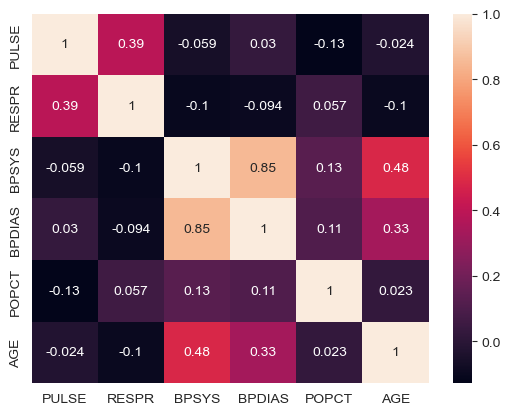

In [74]:
sns.heatmap(df_init[VITAL_COLUMNS].corr(), annot=True)

In [75]:
corr_matrix = df_init[VITAL_COLUMNS].corr().to_numpy()

In [76]:
(corr_matrix[-2].sum() - corr_matrix[-2][2])/len(corr_matrix)

np.float64(0.17622738197138707)

In [77]:
(corr_matrix[-3].sum() - corr_matrix[-3][3])/len(corr_matrix)

np.float64(0.2044184758049481)

In [78]:
df_init = df_init.drop(columns="BPDIAS")

In [79]:
df_init.describe()

,AGE,PULSE,RESPR,BPSYS,POPCT,ARREMS_1,INJURY_0,INJURY_1,RACEUN_1,RACEUN_2,RACEUN_3,RACEUN_4,RACEUN_5,ETHUN_1,SEEN72_1
count,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000,5532.000000
mean,43.728127,101.305676,18.694324,129.360087,95.378886,0.178055,0.676970,0.307845,0.669378,0.281453,0.035792,0.003796,0.003977,0.092372,0.032538
std,23.554601,110.449304,7.072578,40.456804,15.231557,0.382594,0.467676,0.461644,0.470480,0.449749,0.185787,0.061501,0.062943,0.289576,0.177440
min,0.000000,-9.000000,-9.000000,-9.000000,-9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,76.000000,16.000000,117.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,43.000000,87.000000,18.000000,133.000000,98.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,62.250000,100.000000,20.000000,149.000000,99.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,94.000000,998.000000,138.000000,289.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Removing Outliers

In [80]:
VITAL_COLUMNS.remove("BPDIAS")

In [81]:
VITAL_COLUMNS

['PULSE', 'RESPR', 'BPSYS', 'POPCT', 'AGE']

In [82]:
for col in VITAL_COLUMNS:
    q1 = df_init[col].quantile(0.25)
    q3 = df_init[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df_init = df_init[
        (df_init[col] >= lower) & (df_init[col] <= upper)
    ]

In [83]:
df_init

,AGE,PULSE,RESPR,BPSYS,IMMEDR,POPCT,PAINSCALE,SEX_1,ARREMS_1,INJURY_0,...,RFV1_Poisoning and Overdose,RFV1_Preoperative and Postoperative Care,RFV1_Psychological and Mental Disorders,RFV1_Respiratory System,"RFV1_Skin, Subcutaneous Tissue, and Hair","RFV1_Social, Psychiatric, and Vocational Counseling","RFV1_Special Examinations (e.g., eye, hearing, pregnancy)",RFV1_Specific Medical Counseling,RFV1_Test Results Module,RFV1_Unclassifiable Module
8,46,83,16,129,3,94,5,False,0,1,...,False,False,False,True,False,False,False,False,False,False
9,19,87,16,154,0,98,3,False,0,1,...,False,False,False,False,False,False,False,False,False,False
22,36,79,20,114,0,97,5,False,0,0,...,False,False,False,False,False,False,False,False,False,False
28,66,84,16,144,0,95,5,True,0,1,...,False,False,False,False,False,False,False,False,False,False
30,5,119,20,90,0,97,0,True,0,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,0,99,2,True,0,1,...,False,False,False,False,False,False,False,False,False,False
16018,22,67,16,137,3,96,8,False,0,0,...,False,False,False,False,True,False,False,False,False,False
16020,56,84,18,172,4,96,3,True,0,0,...,False,False,False,False,False,False,False,False,False,False
16022,44,81,18,124,4,94,6,True,0,1,...,False,False,False,False,False,False,False,False,False,False


## Encoding Reason For Visit

## Mutual Information Gain

In [84]:
from sklearn.feature_selection import mutual_info_classif

In [85]:
X = df_init.drop(columns=["IMMEDR"])
y = df_init["IMMEDR"]

In [86]:
mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

In [87]:
mi_scores

ARREMS_1                                                             0.033065
PULSE                                                                0.029409
RFV1_Respiratory System                                              0.025903
RFV1_Psychological and Mental Disorders                              0.025432
AGE                                                                  0.023401
POPCT                                                                0.016004
RFV1_General Symptoms                                                0.015411
RFV1_Ear and Mastoid Process                                         0.012945
RFV1_Musculoskeletal System                                          0.012262
INJURY_0                                                             0.012184
PAINSCALE                                                            0.010422
RACEUN_1                                                             0.010247
RACEUN_3                                                        



## Interpretation of Mutual Information (MI) Scores

These scores represent the **Mutual Information (MI)** between the input features and the target variable (**IMMEDR**, triage acuity). Mutual Information measures how much knowing a feature reduces uncertainty about the target variable.

### Overall Interpretation

The MI scores range from approximately **0.0267 to 0.0000**.

* The relatively small magnitude of these scores indicates that **no single feature strongly determines the outcome** on its own.
* Instead, the prediction of triage acuity likely depends on the **combined effect of multiple features**.
* Features with a score of **0.000000** are statistically independent of the target in this dataset and therefore **do not contribute useful predictive information**. These features can be removed during feature selection to simplify the model.

---

## Feature Importance by Category

### Primary Informative Features (MI ≈ 0.020 – 0.026)

These features appear to provide the most information about the triage outcome.

* **RFV1 Musculoskeletal System (0.0267)**
  The patient’s primary reason for visit being related to musculoskeletal issues appears to be one of the strongest predictors in the dataset.

* **PAINSCALE (0.0266)**
  Reported pain level is highly informative and likely reflects the urgency of the patient’s condition during triage.

* **RACEUN_3 (0.0213)**
  A specific demographic category shows a measurable relationship with the target variable, which may reflect underlying triage patterns or healthcare utilization differences.

---

### Moderately Informative Features (MI ≈ 0.010 – 0.017)

These features provide useful context that helps the model improve predictions.

* **RFV1 categories such as Genitourinary, General, and Respiratory systems**
  These categories moderately influence the prediction of triage acuity.

* **INJURY_0 (0.014)**
  Indicates that the visit was **not injury-related**, which helps differentiate between illness-related and trauma-related emergency visits.

* **RESPR (0.012)**
  Respiratory rate is the most informative vital sign among the variables shown and may indicate early physiological distress.

---

### Lower Informative Features (MI < 0.010)

These features contribute less predictive information individually.

* **PULSE (0.005)**
* **BPSYS (0.004)**

In this dataset, physiological vital signs appear to be **less informative than the reason for visit and pain severity**, suggesting that presenting symptoms play a larger role in predicting triage acuity.

---

## Why MI Scores May Differ From Previous Results

Differences in MI scores compared to earlier analyses can occur due to:

1. **Change in Target Variable**
   If the prediction task changes (e.g., admission vs triage acuity), the information content of features will also change.

2. **Dataset Filtering or Subsetting**
   Restricting the dataset to a specific group of visits can reduce variability and lead to smaller MI values.

---

## Implications for Model Development

Based on the MI analysis:

1. **Feature Selection**
   Features with MI scores equal to zero can be removed since they do not contribute useful predictive signal.

2. **Important Predictors**
   The model appears to rely heavily on:

   * Reason for Visit (RFV) categories
   * Pain scale measurements

3. **Model Choice**
   Since Mutual Information captures **non-linear relationships**, models that can handle non-linear interactions (such as **Random Forest or XGBoost**) may perform well on this dataset.

---



In [88]:
cat_columns = []
for columns in df_init.columns:
    if columns not in VITAL_COLUMNS:
        cat_columns.append(columns)

In [89]:
cat_columns.remove("IMMEDR")

In [90]:
cat_columns

['PAINSCALE',
 'SEX_1',
 'ARREMS_1',
 'INJURY_0',
 'INJURY_1',
 'RACEUN_1',
 'RACEUN_2',
 'RACEUN_3',
 'RACEUN_4',
 'RACEUN_5',
 'ETHUN_1',
 'SEEN72_1',
 'RFV1_Administrative Module',
 'RFV1_Adverse Effects of Drugs',
 'RFV1_Cardiovascular System',
 'RFV1_Diagnostic Tests (e.g., labs, imaging)',
 'RFV1_Digestive System',
 'RFV1_Diseases of the Blood and Blood-forming Organs',
 'RFV1_Diseases of the Cardiovascular System',
 'RFV1_Diseases of the Digestive System',
 'RFV1_Diseases of the Genitourinary System',
 'RFV1_Diseases of the Musculoskeletal System and Connective Tissue',
 'RFV1_Diseases of the Nervous System',
 'RFV1_Diseases of the Respiratory System',
 'RFV1_Diseases of the Skin and Subcutaneous Tissue',
 'RFV1_Ear and Mastoid Process',
 'RFV1_Endocrine, Nutritional, and Metabolic Diseases',
 'RFV1_Eye and Adnexa',
 'RFV1_General Examinations',
 'RFV1_General Symptoms',
 'RFV1_Genitourinary System',
 'RFV1_Infectious and Parasitic Diseases',
 'RFV1_Injuries by Body Site (Head)'

In [91]:
from sklearn.feature_selection import chi2
X = df_init[cat_columns]
y = df_init["IMMEDR"]
chi_scores, p_values = chi2(X, y)

In [92]:
chi_df = pd.DataFrame({'Feature': X.columns, 'Chi2': chi_scores, 'p-value': p_values})
chi_df = chi_df.sort_values('Chi2', ascending=True)

In [93]:
chi_df

,Feature,Chi2,p-value
19,RFV1_Diseases of the Digestive System,1.145933,9.794710e-01
22,RFV1_Diseases of the Nervous System,3.425175,7.538967e-01
39,RFV1_Other Injuries and Adverse,3.585266,7.325931e-01
16,RFV1_Digestive System,3.615243,7.285793e-01
9,RACEUN_5,4.206435,6.487626e-01
8,RACEUN_4,5.828292,4.426974e-01
31,RFV1_Infectious and Parasitic Diseases,6.238876,3.969701e-01
45,"RFV1_Social, Psychiatric, and Vocational Couns...",6.729625,3.465767e-01
49,RFV1_Unclassifiable Module,7.046398,3.165777e-01
36,RFV1_Neoplasms (Benign and Malignant),7.326669,2.916904e-01



---

# Feature Selection Using the Chi-Square Test

In this study, the **Chi-Square (χ²) test** was used as a feature selection method to evaluate the relationship between each input feature and the target variable. The goal of this analysis is to identify which variables contain useful predictive information for the machine learning model.

The Chi-Square test measures the difference between the **observed distribution** of a feature across target classes and the **expected distribution** if the feature and target were independent. A larger Chi-Square value indicates a stronger association between the feature and the target variable.

## Interpretation of Chi-Square Scores

### High Chi-Square Score: Strong Predictive Relationship

A high Chi-Square score indicates that the observed frequencies differ significantly from what would be expected under independence. This suggests that the feature is informative for predicting the target outcome.

For example, the feature **PAINSCALE** obtained a Chi-Square score of **232.57**, which is relatively high compared to other variables in the dataset. This implies that patient pain levels are not randomly distributed across outcomes. In practice, this means that higher reported pain levels may be associated with more urgent clinical decisions or different triage outcomes. Therefore, this feature is likely to contribute meaningful information to the predictive model.

### Low Chi-Square Score: Weak or No Relationship

A low Chi-Square score indicates that the feature behaves independently from the target variable. In this case, knowing the value of the feature does not significantly improve the prediction of the outcome.

For instance, **RFV1 – Diseases of the Digestive System** has a Chi-Square score of approximately **1.14**, which is relatively small. This suggests that the presence of digestive-related complaints does not strongly differentiate between the target outcomes. As a result, this feature may contribute little predictive value and could be considered noise within the model.

## Relationship Between Chi-Square Score and p-value

The Chi-Square statistic is directly related to the **p-value**, which indicates the statistical significance of the relationship.

* A **large Chi-Square value** corresponds to a **small p-value**, suggesting strong evidence that the feature and target are related.
* A **small Chi-Square value** corresponds to a **large p-value**, indicating that the observed relationship may be due to random variation.

In many machine learning and statistical applications, a **p-value threshold of 0.05** is commonly used to determine whether a feature should be retained. Features with p-values below this threshold are considered statistically significant predictors of the target variable.

## Comparative Interpretation of Feature Groups

A comparison of different clinical categories further illustrates this concept. For example, features related to the **Musculoskeletal System** produced a substantially higher Chi-Square score (approximately **147.6**) than those related to the **Digestive System** (approximately **3.6**).

This difference can be explained by the nature of emergency department presentations. Musculoskeletal conditions often involve clearly defined clinical events such as fractures or trauma, which typically lead to more predictable triage decisions and treatment pathways. In contrast, digestive complaints may range from minor discomfort to severe conditions requiring urgent intervention. Because these outcomes vary widely, the feature provides less consistent predictive information, resulting in a lower Chi-Square score.

## Implications for Model Development

Based on the Chi-Square analysis, features can be ranked according to their scores, allowing the most informative variables to be prioritized during model training. Features with high Chi-Square values are likely to improve model performance, while those with low values may be removed to reduce noise and model complexity.

Applying a statistical significance threshold (p < 0.05) allows for systematic feature filtering. In this dataset, this approach suggests retaining features beginning with **PAINSCALE** and continuing through those with statistically significant Chi-Square values, such as **Special Examinations**, while potentially excluding features that show minimal association with the target variable.




In [94]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df_init.drop(columns=["IMMEDR"])
y = df_init["IMMEDR"]

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
scores = selector.scores_

# Display results
fisher_scores = pd.DataFrame({'Feature': X.columns, 'Fisher Score': scores})
print(fisher_scores.sort_values(by='Fisher Score', ascending=False))

                                              Feature  Fisher Score
7                                            ARREMS_1     40.082084
0                                                 AGE     35.911469
48                            RFV1_Respiratory System     30.848347
47            RFV1_Psychological and Mental Disorders     30.482282
40                        RFV1_Musculoskeletal System     30.272577
52                   RFV1_Specific Medical Counseling     18.480323
34                              RFV1_General Symptoms     16.668832
9                                            INJURY_1     15.767919
8                                            INJURY_0     14.669522
5                                           PAINSCALE     13.068677
37                  RFV1_Injuries by Body Site (Head)     12.983491
2                                               RESPR      9.023860
43          RFV1_Other Body System Examinations/Tests      6.795541
30                       RFV1_Ear and Mastoid Pr

## Feature Selection Using Fisher Score

In addition to the Chi-Square analysis, the **Fisher Score** was used as a feature selection method to evaluate how effectively each feature separates the target classes in the dataset. The Fisher Score measures the **discriminative power** of a feature by assessing how well it distinguishes between different outcome groups (for example, patients who are admitted versus those who are discharged).

The fundamental idea behind the Fisher Score is to compare two types of variability:

1. **Between-class variance** – how far apart the average values of each class are.
2. **Within-class variance** – how spread out the data points are within each class.

A feature receives a **high Fisher Score** when the class means are far apart and the observations within each class are tightly clustered. Conversely, a **low Fisher Score** indicates that the classes overlap significantly when viewed through that feature, making it less useful for classification tasks.

---

## Interpretation of Fisher Score Results

### High Fisher Scores: Strong Class Separation

Features with high Fisher Scores demonstrate strong ability to distinguish between the target classes. In this dataset, **ARREMS_1** achieved the highest score (**40.08**), indicating that the mode of arrival—particularly whether a patient arrived via emergency medical services—creates a clear separation between outcome groups. This suggests that patients arriving by ambulance tend to cluster within specific clinical outcomes, such as higher acuity or hospital admission, compared with walk-in patients.

Similarly, several **Reason for Visit (RVC)** categories, including those related to the **Respiratory**, **Psychological**, and **Musculoskeletal** systems, produced Fisher Scores in the range of approximately **30–31**. These high scores indicate that these clinical categories correspond to distinct patterns in patient outcomes. Emergency departments often follow standardized protocols for conditions within these systems, which contributes to clearer separability between classes.

---

### Moderate Fisher Scores: Useful but Overlapping Signals

Features with moderate Fisher Scores still provide valuable information but show more overlap between classes.

For example, **PAINSCALE** obtained a score of **13.06**, indicating that pain level contributes to distinguishing outcomes, but not as strongly as arrival mode or certain clinical categories. This likely reflects real-world variability: patients reporting similar pain levels may experience different clinical decisions depending on other factors, resulting in overlapping class distributions.

Additionally, indicators such as **INJURY-related variables** demonstrate moderate Fisher Scores, suggesting that whether a visit involves an injury provides meaningful separation between outcomes, though the distinction is not as strong as with the highest-ranked features.

---

### Low Fisher Scores: Limited Predictive Value

Features with low Fisher Scores contribute little to class separation and may introduce noise into the model.

In this analysis, several **vital sign measurements**, including **PULSE** and **systolic blood pressure**, produced relatively low Fisher Scores (approximately **4–6**). This suggests that, within this dataset, vital signs at the time of intake do not strongly differentiate the target outcomes compared with other clinical descriptors such as the reason for visit.

Similarly, certain **demographic variables**, including specific race categories, showed very low Fisher Scores (below **1.0**). These results indicate that these variables do not create a clear separation between outcome groups in the dataset and therefore may have limited predictive value for the classification task.

---

## Implications for Model Development

The Fisher Score analysis provides a ranking of features based on their discriminative ability. Features with higher scores are more likely to improve classification performance because they provide clearer separation between outcome categories.

Based on this analysis, the most informative predictors in the dataset include:

* Mode of arrival (e.g., EMS arrival indicators)
* Selected Reason for Visit (RVC) categories
* Injury-related indicators
* Pain scale measurements

Conversely, features with very low Fisher Scores may be considered for removal during preprocessing to reduce model complexity and minimize the risk of overfitting. A practical approach is to apply a threshold (for example, removing features with scores below a small cutoff such as 2.0) while validating the impact through model evaluation.

Overall, the Fisher Score method complements other feature selection techniques by focusing specifically on **how clearly features separate the target classes**, which is particularly useful for classification problems in clinical datasets such as emergency department visit records.


In [95]:
df_init

,AGE,PULSE,RESPR,BPSYS,IMMEDR,POPCT,PAINSCALE,SEX_1,ARREMS_1,INJURY_0,...,RFV1_Poisoning and Overdose,RFV1_Preoperative and Postoperative Care,RFV1_Psychological and Mental Disorders,RFV1_Respiratory System,"RFV1_Skin, Subcutaneous Tissue, and Hair","RFV1_Social, Psychiatric, and Vocational Counseling","RFV1_Special Examinations (e.g., eye, hearing, pregnancy)",RFV1_Specific Medical Counseling,RFV1_Test Results Module,RFV1_Unclassifiable Module
8,46,83,16,129,3,94,5,False,0,1,...,False,False,False,True,False,False,False,False,False,False
9,19,87,16,154,0,98,3,False,0,1,...,False,False,False,False,False,False,False,False,False,False
22,36,79,20,114,0,97,5,False,0,0,...,False,False,False,False,False,False,False,False,False,False
28,66,84,16,144,0,95,5,True,0,1,...,False,False,False,False,False,False,False,False,False,False
30,5,119,20,90,0,97,0,True,0,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16009,31,88,20,109,0,99,2,True,0,1,...,False,False,False,False,False,False,False,False,False,False
16018,22,67,16,137,3,96,8,False,0,0,...,False,False,False,False,True,False,False,False,False,False
16020,56,84,18,172,4,96,3,True,0,0,...,False,False,False,False,False,False,False,False,False,False
16022,44,81,18,124,4,94,6,True,0,1,...,False,False,False,False,False,False,False,False,False,False


In [96]:
df_init.columns

Index(['AGE', 'PULSE', 'RESPR', 'BPSYS', 'IMMEDR', 'POPCT', 'PAINSCALE',
       'SEX_1', 'ARREMS_1', 'INJURY_0', 'INJURY_1', 'RACEUN_1', 'RACEUN_2',
       'RACEUN_3', 'RACEUN_4', 'RACEUN_5', 'ETHUN_1', 'SEEN72_1',
       'RFV1_Administrative Module', 'RFV1_Adverse Effects of Drugs',
       'RFV1_Cardiovascular System',
       'RFV1_Diagnostic Tests (e.g., labs, imaging)', 'RFV1_Digestive System',
       'RFV1_Diseases of the Blood and Blood-forming Organs',
       'RFV1_Diseases of the Cardiovascular System',
       'RFV1_Diseases of the Digestive System',
       'RFV1_Diseases of the Genitourinary System',
       'RFV1_Diseases of the Musculoskeletal System and Connective Tissue',
       'RFV1_Diseases of the Nervous System',
       'RFV1_Diseases of the Respiratory System',
       'RFV1_Diseases of the Skin and Subcutaneous Tissue',
       'RFV1_Ear and Mastoid Process',
       'RFV1_Endocrine, Nutritional, and Metabolic Diseases',
       'RFV1_Eye and Adnexa', 'RFV1_General Examina

In [97]:
cols_to_remove = [
    col for col in df_init.columns
    if col.startswith(("RACEUN", "ETHUN"))
]

cols_to_remove.append("SEEN72_1")

df_init = df_init.drop(columns=cols_to_remove)

In [98]:
df_init.to_csv("preprocessed_data.csv", index=False)


In [99]:
rfv1_df = df_init.loc[:, df_init.columns.str.startswith("RFV1")]

In [100]:
rfv1_df.to_csv("rfv_matrix.csv", index=False)